In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim

In [11]:
class PINN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net=nn.Sequential(
            nn.Linear(3,32),
            nn.Tanh(),
            nn.Linear(32,64),
            nn.Tanh(),
            nn.Linear(64,16),
            nn.Tanh(),
            nn.Linear(16,1)
        )
    
    def forward(self,t,y1,y2):
        x=torch.cat([t,y1,y2],dim=1)
        return self.net(x)
    def loss(self,t,y1,y2,r,K1,K2,sigma):
        t.requires_grad_(True)
        y1.requires_grad_(True)
        y2.requires_grad_(True)

        w1=self.forward(t,y1,y2)
        w2=self.forward(t,y2,y1)

        dw1=torch.autograd.grad(w1,y1,grad_outputs=torch.ones_like(w1),create_graph=True)[0]
        dw2=torch.autograd.grad(w1,y2,grad_outputs=torch.ones_like(w1),create_graph=True)[0]

        dw3=torch.autograd.grad(w1,t,grad_outputs=torch.ones_like(w1),create_graph=True)[0]

        d2wd11=torch.autograd.grad(dw1,y1,grad_outputs=torch.ones_like(w1),create_graph=True)[0]
        d2wd22=torch.autograd.grad(dw2,y2,grad_outputs=torch.ones_like(w1),create_graph=True)[0]

        val=(K1+K2)*dw3*(dw1-dw2)+r*(K1*y1+K2*y2)*(dw1**2-dw2**2)-r*dw1*(K1*w1+K2*w2)+r*dw2*(K2*w1+K1*w2)
        term=(K1*(y1**2)+K2*(y2**2))*(d2wd11*dw1-d2wd22*dw2)-(K1*(y2**2)+K2*(y1**2))*(d2wd11*dw2-d2wd22*dw1)
        val+=0.5*sigma*sigma*(term)

        return torch.mean(val**2)
    def basecase_loss(self,y1,y2,t0,c):
        t=torch.full_like(y1,t0)
        W1=self.forward(t,y1,y2)
        W2=self.forward(t,y2,y1)
        return torch.mean((W1-torch.relu(y1-c))**2+(W2-torch.relu(y2-c))**2)



In [14]:
def train(model):
    r=0.05
    K1=0.5
    K2=0.5
    sigma=0.1
    C=100
    t0=10
    epochs=5000
    batch_size=1000
    optimizer=optim.Adam(model.parameters(),lr=1e-3)

    for epoch in range(epochs):
        optimizer.zero_grad()
        t_colloc = torch.rand((batch_size, 1)) * t0
        y1_colloc = torch.rand((batch_size, 1)) * (2 * C) # Sample prices from 0 to 200
        y2_colloc = torch.rand((batch_size, 1)) * (2 * C)

        # Randomly sample points for the terminal boundary
        y1_term = torch.rand((batch_size, 1)) * (2 * C)
        y2_term = torch.rand((batch_size, 1)) * (2 * C)

        # Calculate losses
        loss_pde = model.loss(t_colloc, y1_colloc, y2_colloc, r, K1, K2, sigma)
        loss_term = model.basecase_loss(y1_term, y2_term, t0, C)

        # Total loss (you can weigh these differently if one dominates)
        total_loss = loss_pde + loss_term

        total_loss.backward()
        optimizer.step()

        if epoch % 500 == 0:
            print(f"Epoch {epoch}: PDE Loss = {loss_pde.item():.6f}, Terminal Loss = {loss_term.item():.6f}")

    return model

In [15]:
pricing_function=PINN()
train(pricing_function)

Epoch 0: PDE Loss = 0.000002, Terminal Loss = 3571.547607
Epoch 500: PDE Loss = 0.426431, Terminal Loss = 2290.229004
Epoch 1000: PDE Loss = 0.987155, Terminal Loss = 1741.818481
Epoch 1500: PDE Loss = 1.568484, Terminal Loss = 1410.711060
Epoch 2000: PDE Loss = 1.103368, Terminal Loss = 1055.425903
Epoch 2500: PDE Loss = 0.716216, Terminal Loss = 801.455505
Epoch 3000: PDE Loss = 0.345136, Terminal Loss = 556.436462
Epoch 3500: PDE Loss = 0.208434, Terminal Loss = 423.071381
Epoch 4000: PDE Loss = 0.313171, Terminal Loss = 292.860291
Epoch 4500: PDE Loss = 0.342709, Terminal Loss = 223.603470


PINN(
  (net): Sequential(
    (0): Linear(in_features=3, out_features=32, bias=True)
    (1): Tanh()
    (2): Linear(in_features=32, out_features=64, bias=True)
    (3): Tanh()
    (4): Linear(in_features=64, out_features=16, bias=True)
    (5): Tanh()
    (6): Linear(in_features=16, out_features=1, bias=True)
  )
)

In [18]:
train(pricing_function)

Epoch 0: PDE Loss = 0.355497, Terminal Loss = 0.507523
Epoch 500: PDE Loss = 0.305309, Terminal Loss = 0.231057
Epoch 1000: PDE Loss = 0.265169, Terminal Loss = 0.261583
Epoch 1500: PDE Loss = 0.217769, Terminal Loss = 0.207750
Epoch 2000: PDE Loss = 0.206083, Terminal Loss = 0.288013
Epoch 2500: PDE Loss = 0.108878, Terminal Loss = 0.101042
Epoch 3000: PDE Loss = 0.114281, Terminal Loss = 0.083522
Epoch 3500: PDE Loss = 0.091017, Terminal Loss = 0.091255
Epoch 4000: PDE Loss = 0.113212, Terminal Loss = 0.502346
Epoch 4500: PDE Loss = 0.086389, Terminal Loss = 0.063173


PINN(
  (net): Sequential(
    (0): Linear(in_features=3, out_features=32, bias=True)
    (1): Tanh()
    (2): Linear(in_features=32, out_features=64, bias=True)
    (3): Tanh()
    (4): Linear(in_features=64, out_features=16, bias=True)
    (5): Tanh()
    (6): Linear(in_features=16, out_features=1, bias=True)
  )
)

In [19]:
torch.save(pricing_function.state_dict(), 'model.pth')
model=PINN()
model.load_state_dict(torch.load('model.pth', weights_only=True))


<All keys matched successfully>

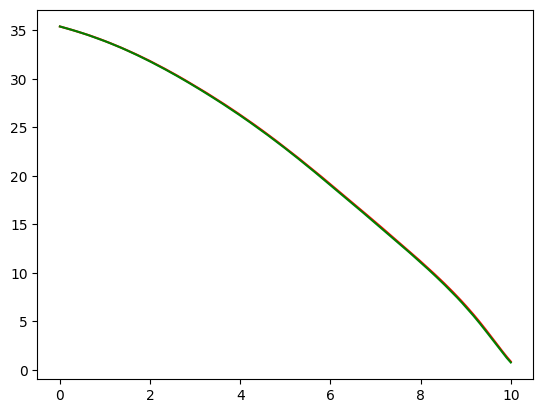

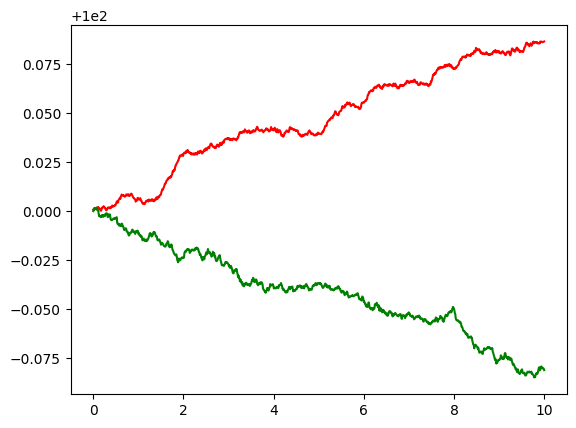

In [33]:
model.eval()

# Example: 5 specific points in time and space
t_vals  = np.linspace(0,10,1000)
y1_vals = 100+np.cumsum(np.random.randn(1000)*0.0005+0.0001)
y2_vals = 100+np.cumsum(np.random.randn(1000)*0.0007-0.0001)

with torch.no_grad():
    # Convert to tensors and reshape to (N, 1) column vectors
    t_tensor  = torch.tensor(t_vals, dtype=torch.float32).view(-1, 1)
    y1_tensor = torch.tensor(y1_vals, dtype=torch.float32).view(-1, 1)
    y2_tensor = torch.tensor(y2_vals, dtype=torch.float32).view(-1, 1)
    
    # Predict all 5 points in a single vectorized pass
    w_preds1 = model(t_tensor, y1_tensor, y2_tensor)
    w_preds2= model(t_tensor, y2_tensor, y1_tensor)
plt.plot(t_vals,w_preds1,color="red")
plt.plot(t_vals,w_preds2,color="green")
plt.show()
plt.plot(t_vals,y1_vals,color="red")
plt.plot(t_vals,y2_vals,color="green")
plt.show()